# Explorations and Analyses of the ENTSO-E data

In [2]:
# Fix the path 
import sys
import os

sys.path.append(os.path.abspath(".."))  # since you're in src/data_analysis
os.environ["ENTSOE_API_KEY"] = "ec10538b-eae1-4d71-ada6-45feff2e51c2"
os.environ["QUANT_DB_HOST"] = "localhost"
os.environ["QUANT_DB_PORT"] = "5432"
os.environ["QUANT_DB_NAME"] = "options_db"
os.environ["QUANT_DB_USER"] = "quant_user"
os.environ["QUANT_DB_PASSWORD"] = "strong_password"


In [3]:
# import necessary libraries
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure notebook picks up local code edits without kernel restarts
%load_ext autoreload
%autoreload 2

# custom imports
import electricity_price_predictor.entsoe_api as api
import electricity_price_predictor.pipeline as pipeline

importlib.reload(api)
importlib.reload(pipeline)

from electricity_price_predictor.db import get_engine
from electricity_price_predictor.pipeline import run_feature_pipeline


In [4]:
def access_data(
    start: pd.Timestamp,
    end: pd.Timestamp,
    country_code: str,
    history_hours: int = 48,
) -> pd.DataFrame:
    """
    Fetch features for [start, end) while pulling extra lookback history.

    We need lookback because feature generation creates lagged columns (t-1..t-24)
    and drops rows with NaNs.
    """
    api_key = os.getenv("ENTSOE_API_KEY")
    if not api_key:
        raise RuntimeError("ENTSOE_API_KEY environment variable is required.")

    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    if start_ts.tz is None:
        start_ts = start_ts.tz_localize("UTC")
    else:
        start_ts = start_ts.tz_convert("UTC")

    if end_ts.tz is None:
        end_ts = end_ts.tz_localize("UTC")
    else:
        end_ts = end_ts.tz_convert("UTC")

    engine = get_engine()
    pipeline_start = start_ts - pd.Timedelta(hours=history_hours)

    features = run_feature_pipeline(
        engine=engine,
        entsoe_api_key=api_key,
        country_code=country_code,
        start=pipeline_start,
        end=end_ts,
        cache_ttl_hours=24,
    )

    # Return only the user-requested interval.
    return features[(features.index >= start_ts) & (features.index < end_ts)]



In [5]:
# Pull the latest 48h window ending at the most recent complete hour.
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=48)

df_CH = access_data(start, end, "CH", history_hours=72)


# pull German data for comparison 
df_DE = access_data(start, end, "DE_LU", history_hours=72)
# pull French data for comparison 
df_FR = access_data(start, end, "FR", history_hours=72)
# pull Italian data for comparison 
df_IT = access_data(start, end, "IT", history_hours=72)
# pull Austrian data for comparison 
df_AT = access_data(start, end, "AT", history_hours=72)
# pull Spanish data for comparison 
df_ES = access_data(start, end, "ES", history_hours=72)




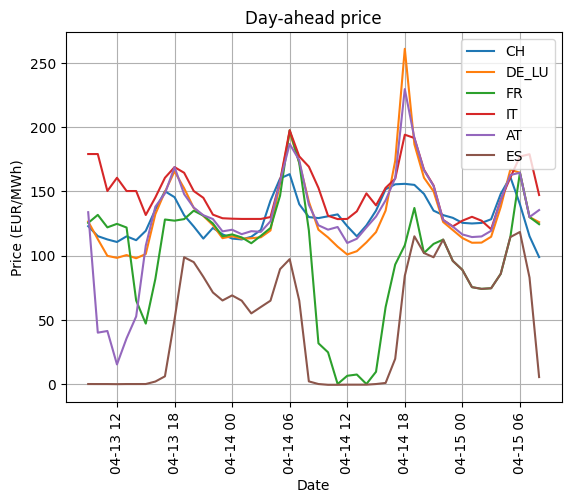

In [6]:
plt.plot(df_CH.index, df_CH["day_ahead_price"], label="CH")
plt.plot(df_DE.index, df_DE["day_ahead_price"], label="DE_LU")
plt.plot(df_FR.index, df_FR["day_ahead_price"], label="FR")
plt.plot(df_IT.index, df_IT["day_ahead_price"], label="IT")
plt.plot(df_AT.index, df_AT["day_ahead_price"], label="AT")
plt.plot(df_ES.index, df_ES["day_ahead_price"], label="ES")

plt.xticks(rotation=90)
plt.grid()
plt.title("Day-ahead price")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()

plt.show()




## Feature engineering 
In the next section we are going to explore which features are justifiable with the given data. 

In [7]:
df_CH.columns

Index(['day_ahead_price', 'load_forecast', 'wind_forecast', 'solar_forecast',
       'residual_load', 'lagged_price_1', 'lagged_residual_load_1',
       'lagged_price_2', 'lagged_residual_load_2', 'lagged_price_3',
       'lagged_residual_load_3', 'lagged_price_4', 'lagged_residual_load_4',
       'lagged_price_5', 'lagged_residual_load_5', 'lagged_price_6',
       'lagged_residual_load_6', 'lagged_price_7', 'lagged_residual_load_7',
       'lagged_price_8', 'lagged_residual_load_8', 'lagged_price_9',
       'lagged_residual_load_9', 'lagged_price_10', 'lagged_residual_load_10',
       'lagged_price_11', 'lagged_residual_load_11', 'lagged_price_12',
       'lagged_residual_load_12', 'lagged_price_13', 'lagged_residual_load_13',
       'lagged_price_14', 'lagged_residual_load_14', 'lagged_price_15',
       'lagged_residual_load_15', 'lagged_price_16', 'lagged_residual_load_16',
       'lagged_price_17', 'lagged_residual_load_17', 'lagged_price_18',
       'lagged_residual_load_18', 'lag

<Axes: >

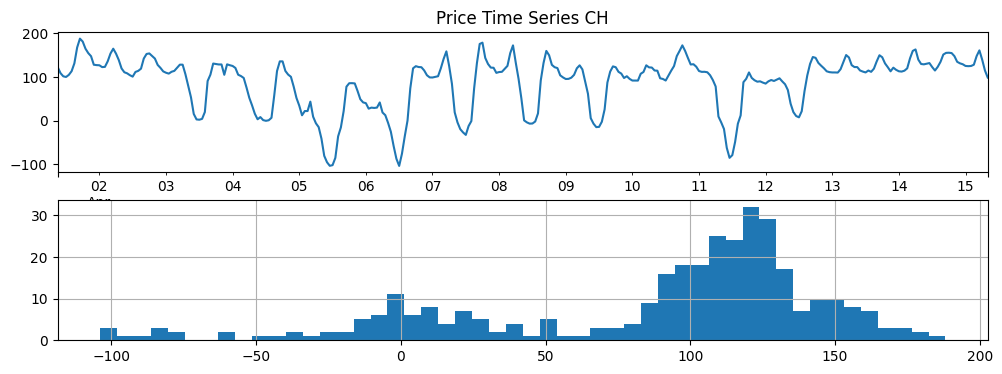

In [10]:
fig, axes = plt.subplots(2,1,figsize=(12,4))
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=14*24)
df = access_data(start, end, "CH", history_hours=72)
df["day_ahead_price"].plot(ax = axes[0], title = "Price Time Series CH")
df["day_ahead_price"].hist(bins=50, ax = axes[1])

Observations: 

* Intraday seasonality 
* $\mu \approx 125$
* Noise 

An approach could be to model it as 

Price(t) = µ + seasonal(t) + noise

In [ ]:
# Let's explore this further with an STL decomposition 
from statsmodels.tsa.seasonal import STL 

ts = df["day_ahead_price"]

stl = STL(ts, period=24)
res = stl.fit()

res.plot()


